In [48]:
print("Hello World")

Hello World


In [49]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [50]:
df = pd.read_csv('files/co2.csv')

print(df.head())
print(df.shape)
print(df.isnull().sum())


    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                               9.6   
2                   

In [51]:
num_df = df.select_dtypes(include=['int64', 'float64'])
numeric_columns = num_df.columns

corr_matrix = num_df.corr()

target = 'CO2 Emissions(g/km)'

target_corr = corr_matrix[target].sort_values(ascending=False)
print("\nCorrelation with target:")
print(target_corr)


Correlation with target:
CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


In [52]:
exclude_features = [
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (mpg)'
]


In [53]:
final_features = [
    col for col in num_df.columns
    if col not in exclude_features and col != target
]

print("\nFinal features used for modeling:")
print(final_features)



Final features used for modeling:
['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']


In [54]:
print("\nCorrelation matrix of final selected features:")
print(df[final_features + [target]].corr())



Correlation matrix of final selected features:
                                  Engine Size(L)  Cylinders  \
Engine Size(L)                          1.000000   0.927653   
Cylinders                               0.927653   1.000000   
Fuel Consumption Comb (L/100 km)        0.817060   0.780534   
CO2 Emissions(g/km)                     0.851145   0.832644   

                                  Fuel Consumption Comb (L/100 km)  \
Engine Size(L)                                            0.817060   
Cylinders                                                 0.780534   
Fuel Consumption Comb (L/100 km)                          1.000000   
CO2 Emissions(g/km)                                       0.918052   

                                  CO2 Emissions(g/km)  
Engine Size(L)                               0.851145  
Cylinders                                    0.832644  
Fuel Consumption Comb (L/100 km)             0.918052  
CO2 Emissions(g/km)                          1.000000  


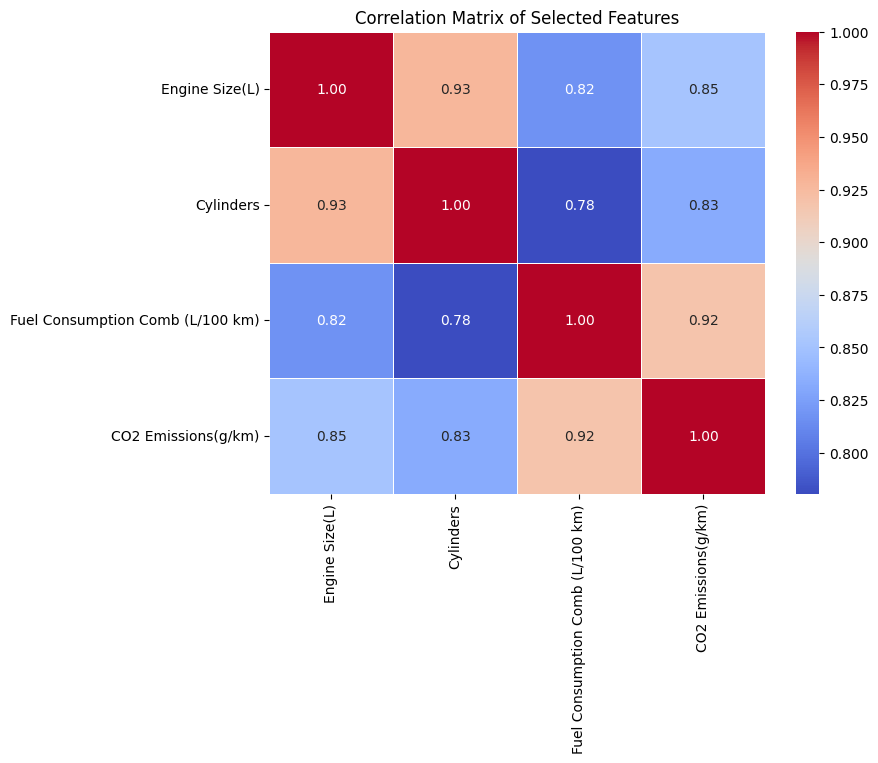

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[final_features + [target]].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Selected Features")
plt.show()


In [56]:
print(final_features)

['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']


In [57]:
X = df[final_features].values
Y = df[target].values



In [58]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std


In [59]:
X = df[final_features].values
y = df[target].values

# Feature scaling (IMPORTANT for gradient descent)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X = (X - X_mean) / X_std


In [60]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=2000):
        self.lr = learning_rate
        self.iterations = iterations
        self.costs = []

    def fit(self, X, y):
        self.m, self.n = X.shape
        self.w = np.zeros(self.n)
        self.b = 0

        for _ in range(self.iterations):
            y_pred = self.predict(X)

            dw = (2/self.m) * X.T.dot(y_pred - y)
            db = (2/self.m) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            cost = np.mean((y - y_pred) ** 2)
            self.costs.append(cost)

    def predict(self, X):
        return X.dot(self.w) + self.b


In [61]:
model = LinearRegressionGD(learning_rate=0.01, iterations=2000)
model.fit(X, y)

print("Weights:", model.w)
print("Bias:", model.b)


Weights: [ 7.73233392 11.60417749 38.33570114]
Bias: 250.58469871360796


In [62]:
y_pred = model.predict(X)

# RMSE
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

# R-squared
ss_total = np.sum((y - np.mean(y)) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
r2 = 1 - ss_res / ss_total

print("\nRMSE:", rmse)
print("R-squared:", r2)



RMSE: 20.33605229629364
R-squared: 0.8791929886490766


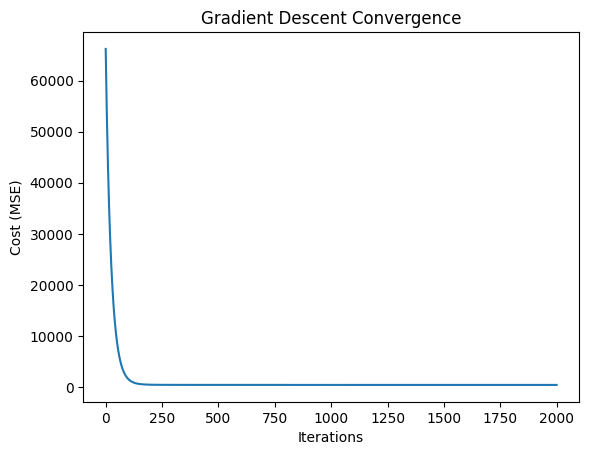

In [63]:
plt.plot(model.costs)
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.show()
